### Liberaries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Helper Functions

In [2]:
def stationary_solution(x, b, sigma, boundary):

    bc_1, bc_2 = boundary
    if b == 0:
        p = np.ones_like(x) / (bc_2 - bc_1)
    else:
        k = 2 * b / sigma**2
        const = (np.exp(k * bc_2) - np.exp(k * bc_1)) / k
        p = np.exp(k * x) / const

    return p


# x dependent drift 
def b_x(x=0):
    return x

# x dependet diffusion
def sigma_x(x=1):
    return x

### One step functions

In [3]:
def apply_boundary(proposal, X_current, boundary_type, boundaries):

    bc_1, bc_2 = boundaries

    if isinstance(boundary_type, tuple) and boundary_type[0] == "theta":
        theta = boundary_type[1]

        outside = (proposal < bc_1) | (proposal > bc_2)

        reflected = proposal.copy()
        left = reflected < bc_1
        right = reflected > bc_2

        while np.any(left) or np.any(right):

            reflected[left] = 2 * bc_1 - reflected[left]
            reflected[right] = 2 * bc_2 - reflected[right]

            left = reflected < bc_1
            right = reflected > bc_2

        proposal[outside] = (theta * reflected[outside] + (1-theta) * X_current[outside])

        return proposal


    elif boundary_type == "reflection":

        left = proposal < bc_1
        right = proposal > bc_2

        while np.any(left) or np.any(right):

            proposal[left] = 2 * bc_1 - proposal[left]
            proposal[right] = 2 * bc_2 - proposal[right]

            left = proposal < bc_1
            right = proposal > bc_2

        return proposal

    elif boundary_type == "rejection":
        rejected = (proposal < bc_1) | (proposal > bc_2)
        proposal[rejected] = X_current[rejected]

        return proposal

    else:
        raise ValueError(f"{boundary_type= } is unknown")


def euler_maruyama(X_current, dt, b, sigma, boundary_type, boundaries, xi=None):

    if xi is None:
        xi = np.random.normal(0, 1, size=X_current.shape)

    # both b and sigma can be either a numbers or a function
    drift = b_x(X_current) if callable(b) else b
    diffusion = sigma_x(X_current) if callable(sigma) else sigma

    proposal = X_current + drift*dt + diffusion * np.sqrt(dt) * xi

    X_next = apply_boundary(proposal, X_current, boundary_type, boundaries)

    return X_next
    

def numerical_solution(method, X_0, dt, n_steps, b, sigma, boundary_type, boundaries, save_every=None):

    X_current = X_0.copy()

    saved_steps = []
    saved_X = []

    for i in range(n_steps):

        X_current = method(X_current=X_current, dt=dt, b=b, sigma=sigma, boundary_type=boundary_type
                           , boundaries=boundaries)

        step_number = i + 1

        if save_every is not None and step_number % save_every == 0:
            saved_steps.append(step_number)
            saved_X.append(X_current.copy())

    # and save final state
    if save_every is None or saved_steps[-1] != n_steps:
        saved_steps.append(n_steps)
        saved_X.append(X_current.copy())

    return X_current, saved_steps, saved_X

### Plotting Functions

In [4]:
def plot_histogram(X, bins, ax=None, title=None, x_label="x", y_label="density", density=True, x_limit=None):
    
    if ax == None:
        ax = plt.gca()

    if title == None:
        title = "Not set"

    ax.hist(X, bins=bins, density=density, label="Numerical")
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_xlim(x_limit)
    ax.grid(True)


def plot_boundary_layer(X, x_range, bins=50, ax=None, title=None, x_label="x", y_label="density"):

    if ax is None:
        ax = plt.gca()

    if title == None:
        title = "Not set"

    x_range_1, x_range_2 = x_range
    edges = np.linspace(x_range_1, x_range_2, bins + 1)
    
    counts, edges = np.histogram(X, bins=edges)
    bin_widths = np.diff(edges)
    density_estimate = counts / (len(X)*bin_widths)
    centres = 0.5 * (edges[:-1] + edges[1:])

    ax.bar(centres, density_estimate, width=bin_widths, align="center", label="Numerical")
    
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_xlim(x_range_1, x_range_2)
    ax.grid(True)

    return centres, density_estimate, edges

### Initalization

In [5]:
#defind varaibles

n_parts = 1000000
T = 5
dt = 0.01
n_steps = int(T/ dt)
epsilon = np.sqrt(dt)

#set the boundries
bc_1 = 0
bc_2 = 1

#drift and diffusion coefficents
sigma  = 1
b = 1

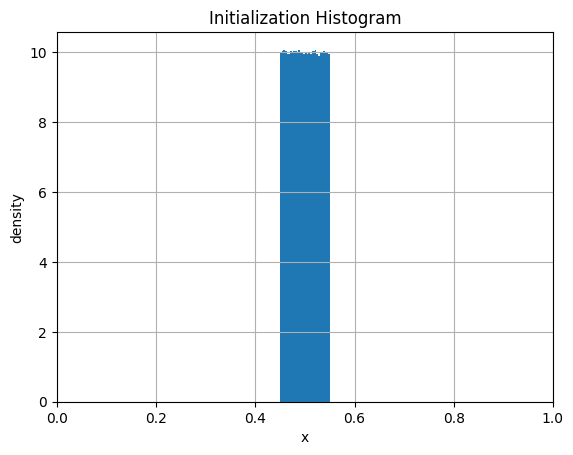

In [6]:

# intial value of the particles
# X_0 = np.random.uniform(bc_1,bc_2, n_parts)
X_0 = np.random.uniform(.45,.55, n_parts)

plot_histogram(X_0, 30, title="Initialization Histogram", x_limit=(bc_1, bc_2))
plt.show()



### Main computaions part of the code

In [7]:


X_ref, steps_ref, solutions_ref = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps
                                                     , b=b, sigma=sigma, boundary_type="reflection"
                                                     , boundaries=(bc_1, bc_2), save_every=None)

X_rej, steps_rej, solutions_rej = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps, b=b, sigma=sigma
                                                     , boundary_type="rejection", boundaries=(bc_1, bc_2)
                                                     , save_every=None)



### plot the exact and numerical solution

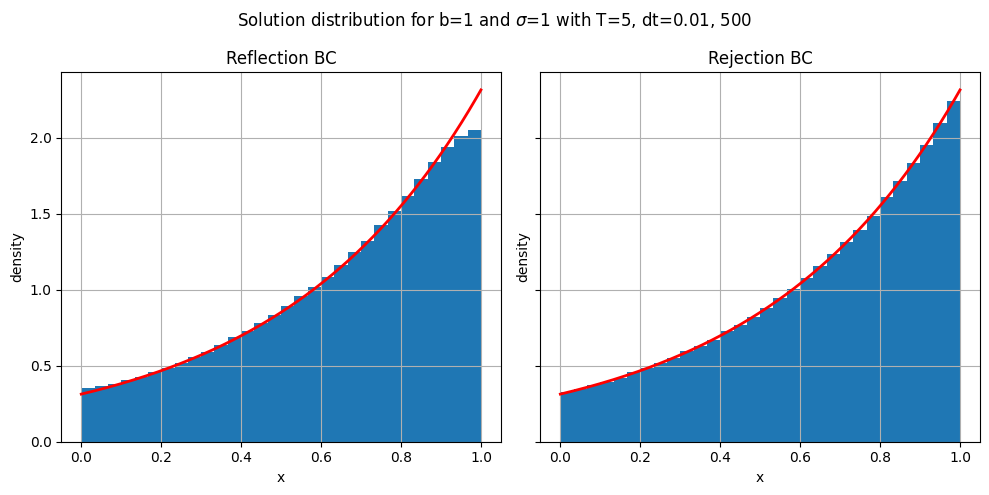

In [8]:
#compute the true solution
x_plot = np.linspace(bc_1, bc_2, 500)
p_exact = stationary_solution(x_plot, b, sigma, (bc_1, bc_2))

# plot full histogram
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True, sharex=True)

fig.suptitle(fr"Solution distribution for {b=} and $\sigma$={sigma} with {T=}, {dt=}, {n_steps}")

plot_histogram(X=X_ref, bins=30, ax=ax[0], title='Reflection BC',x_label='x', y_label='density', density=True
               , x_limit=None)
ax[0].plot(x_plot, p_exact, "r", linewidth=2)

plot_histogram(X=X_rej, bins=30, ax=ax[1], title='Rejection BC', x_label='x', y_label='density', density=True
               , x_limit=None)
ax[1].plot(x_plot, p_exact, "r", linewidth=2)


plt.tight_layout()
plt.show()



### inspect the solution near the boundary

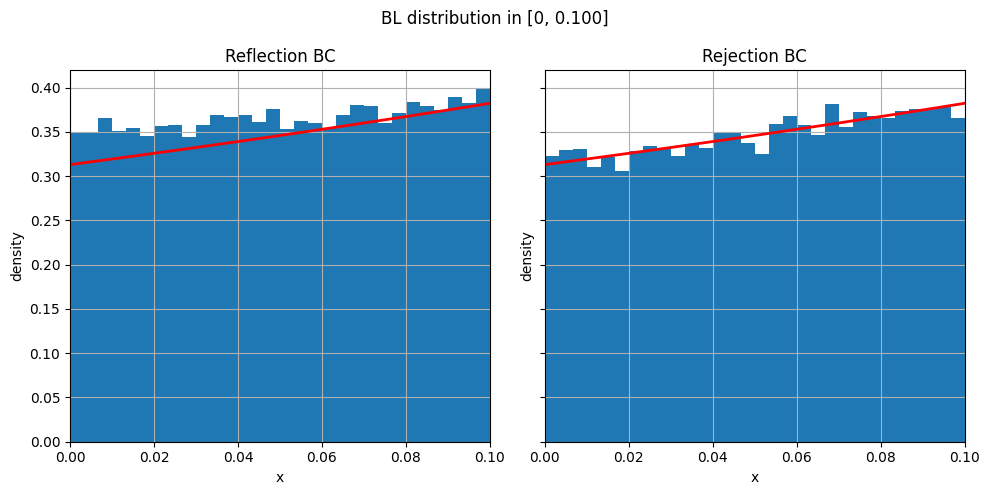

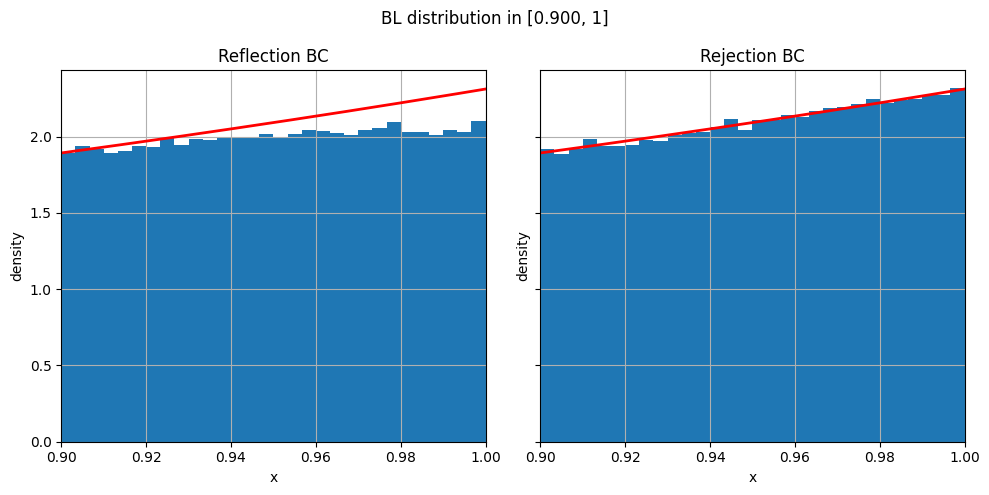

In [9]:

width = 0.1
bins=30

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
fig.suptitle(f"BL distribution in [{bc_1}, {bc_1+width:.3f}]")

plot_boundary_layer(X=X_ref, x_range=(bc_1, bc_1+width), bins=bins, ax=ax[0], title="Reflection BC")
x_plot = np.linspace(bc_1, bc_1 + width, 500)
ax[0].plot(x_plot, stationary_solution(x_plot, b, sigma, (bc_1, bc_2)), "r", linewidth=2, label="True solution")
# ax[0].legend()


plot_boundary_layer(X=X_rej, x_range=(bc_1, bc_1+width), bins=bins, ax=ax[1], title="Rejection BC")
x_plot = np.linspace(bc_1, bc_1 + width, 500)
ax[1].plot(x_plot, stationary_solution(x_plot, b, sigma, (bc_1, bc_2)), "r", linewidth=2, label="True solution")
# ax[1].legend()

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
fig.suptitle(f"BL distribution in [{bc_2-width:.3f}, {bc_2}]")

plot_boundary_layer(X=X_ref, x_range=(bc_2-width, bc_2), bins=bins, ax=ax[0], title="Reflection BC")
x_plot = np.linspace(bc_2-width, bc_2, 500)
ax[0].plot(x_plot, stationary_solution(x_plot, b, sigma, (bc_1, bc_2)), "r", linewidth=2, label="True solution")
# ax[0].legend()


plot_boundary_layer(X=X_rej, x_range=(bc_2-width, bc_2), bins=bins, ax=ax[1], title="Rejection BC")
x_plot = np.linspace(bc_2-width, bc_2, 500)
ax[1].plot(x_plot, stationary_solution(x_plot, b, sigma, (bc_1, bc_2)), "r", linewidth=2, label="True solution")
# ax[1].legend()

plt.tight_layout()
plt.show()

    


### Testing $\theta$-method

In [10]:
T = 5
dt = 0.1
n_steps = int(T/ dt)
epsilon = np.sqrt(dt)

X_ref, steps_ref, solutions_ref = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps
                                                     , b=b, sigma=sigma, boundary_type="reflection"
                                                     , boundaries=(bc_1, bc_2), save_every=None)

X_rej, steps_rej, solutions_rej = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps, b=b, sigma=sigma
                                                     , boundary_type="rejection", boundaries=(bc_1, bc_2)
                                                     , save_every=None)

X_theta, steps_theta, solutions_theta = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps, b=b, sigma=sigma
                                                     , boundary_type=("theta", 0.5) , boundaries=(bc_1, bc_2)
                                                     , save_every=None)


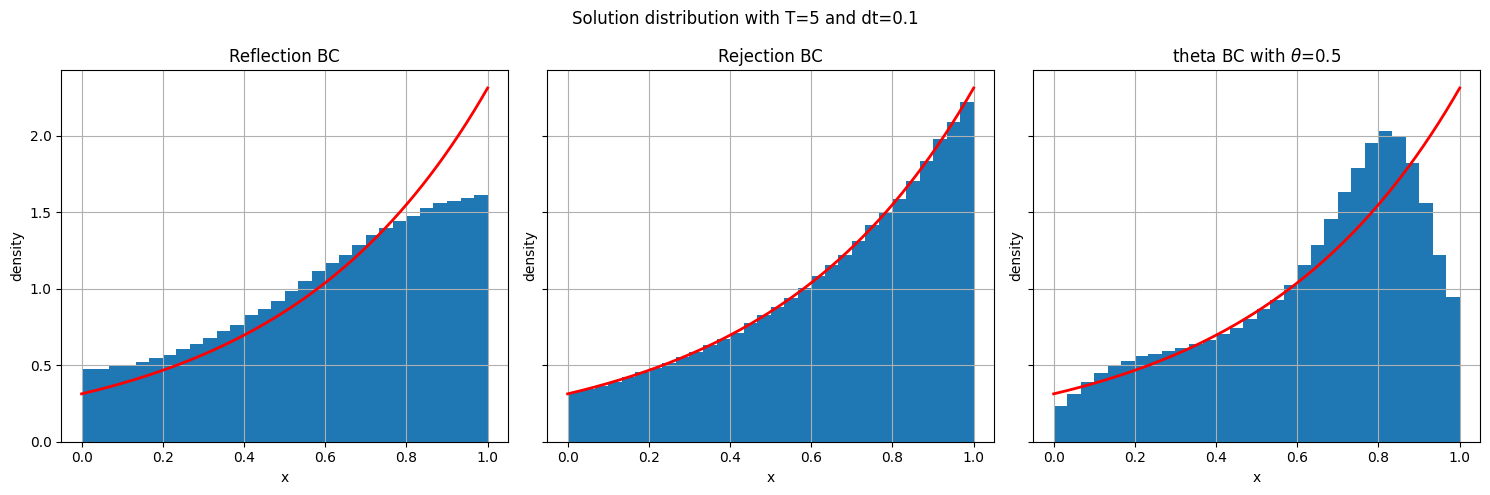

In [11]:
#compute the true solution
x_plot = np.linspace(bc_1, bc_2, 500)
p_exact = stationary_solution(x_plot, b, sigma, (bc_1, bc_2))

# plot full histogram
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)

fig.suptitle(f"Solution distribution with {T=} and {dt=}")

plot_histogram(X=X_ref, bins=30, ax=ax[0], title='Reflection BC',x_label='x', y_label='density', density=True
               , x_limit=None)
ax[0].plot(x_plot, p_exact, "r", linewidth=2)

plot_histogram(X=X_rej, bins=30, ax=ax[1], title='Rejection BC', x_label='x', y_label='density', density=True
               , x_limit=None)
ax[1].plot(x_plot, p_exact, "r", linewidth=2)

plot_histogram(X=X_theta, bins=30, ax=ax[2], title=fr'theta BC with $\theta$={0.5}', x_label='x', y_label='density', density=True
               , x_limit=None)
ax[2].plot(x_plot, p_exact, "r", linewidth=2)

plt.tight_layout()
plt.show()

In [12]:
T = 5
dt = 0.01
n_steps = int(T/ dt)
epsilon = np.sqrt(dt)

X_ref, steps_ref, solutions_ref = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps
                                                     , b=b, sigma=sigma, boundary_type="reflection"
                                                     , boundaries=(bc_1, bc_2), save_every=None)

X_rej, steps_rej, solutions_rej = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps, b=b, sigma=sigma
                                                     , boundary_type="rejection", boundaries=(bc_1, bc_2)
                                                     , save_every=None)

X_theta, steps_theta, solutions_theta = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps, b=b, sigma=sigma
                                                     , boundary_type=("theta", 0.5) , boundaries=(bc_1, bc_2)
                                                     , save_every=None)


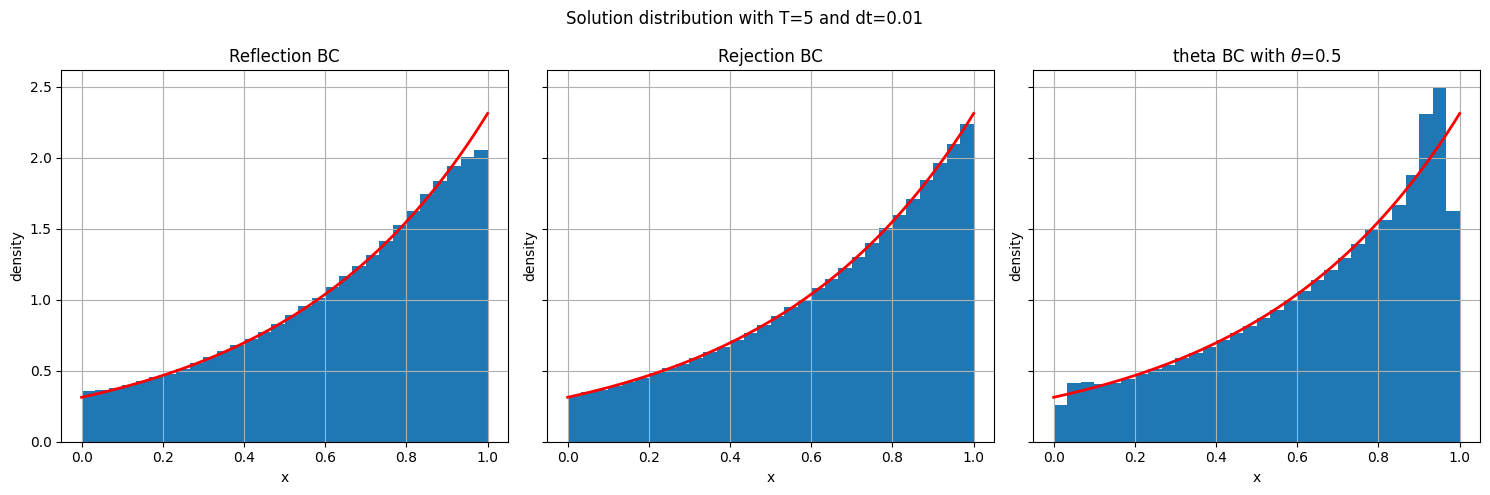

In [13]:
#compute the true solution
x_plot = np.linspace(bc_1, bc_2, 500)
p_exact = stationary_solution(x_plot, b, sigma, (bc_1, bc_2))

# plot full histogram
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)

fig.suptitle(f"Solution distribution with {T=} and {dt=}")

plot_histogram(X=X_ref, bins=30, ax=ax[0], title='Reflection BC',x_label='x', y_label='density', density=True
               , x_limit=None)
ax[0].plot(x_plot, p_exact, "r", linewidth=2)

plot_histogram(X=X_rej, bins=30, ax=ax[1], title='Rejection BC', x_label='x', y_label='density', density=True
               , x_limit=None)
ax[1].plot(x_plot, p_exact, "r", linewidth=2)

plot_histogram(X=X_theta, bins=30, ax=ax[2], title=fr'theta BC with $\theta$={0.5}', x_label='x', y_label='density', density=True
               , x_limit=None)
ax[2].plot(x_plot, p_exact, "r", linewidth=2)

plt.tight_layout()
plt.show()

In [14]:
T = 5
dt = 0.001
n_steps = int(T/ dt)
epsilon = np.sqrt(dt)

X_ref, steps_ref, solutions_ref = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps
                                                     , b=b, sigma=sigma, boundary_type="reflection"
                                                     , boundaries=(bc_1, bc_2), save_every=None)

X_rej, steps_rej, solutions_rej = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps, b=b, sigma=sigma
                                                     , boundary_type="rejection", boundaries=(bc_1, bc_2)
                                                     , save_every=None)

X_theta, steps_theta, solutions_theta = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps, b=b, sigma=sigma
                                                     , boundary_type=("theta", 0.5) , boundaries=(bc_1, bc_2)
                                                     , save_every=None)


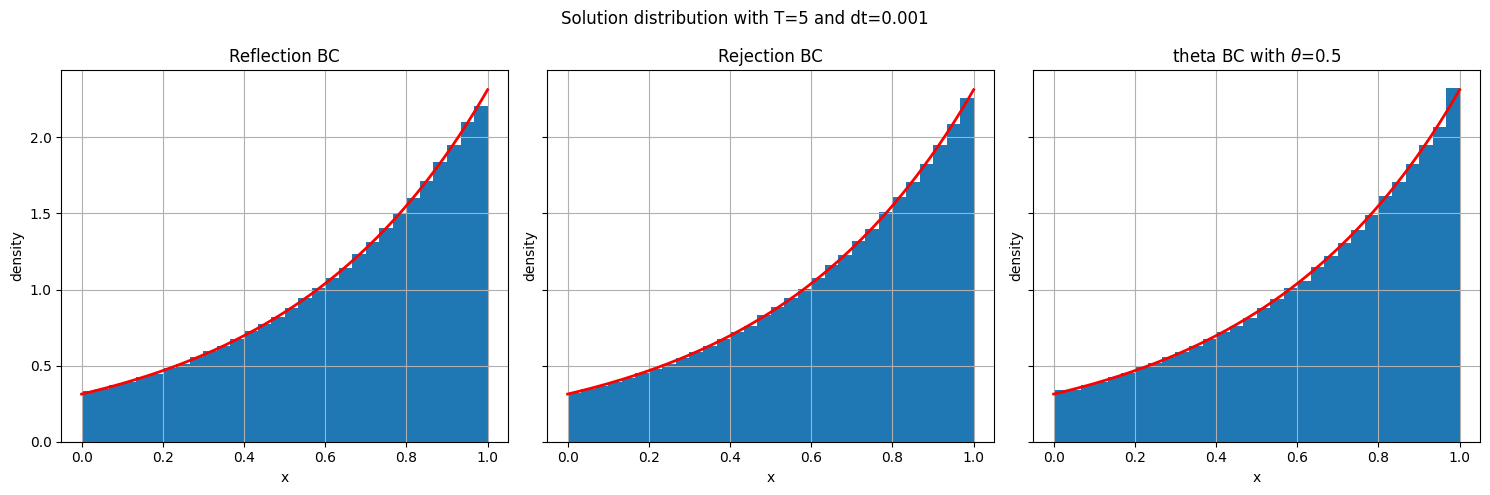

In [15]:
#compute the true solution
x_plot = np.linspace(bc_1, bc_2, 500)
p_exact = stationary_solution(x_plot, b, sigma, (bc_1, bc_2))

# plot full histogram
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)

fig.suptitle(f"Solution distribution with {T=} and {dt=}")

plot_histogram(X=X_ref, bins=30, ax=ax[0], title='Reflection BC',x_label='x', y_label='density', density=True
               , x_limit=None)
ax[0].plot(x_plot, p_exact, "r", linewidth=2)

plot_histogram(X=X_rej, bins=30, ax=ax[1], title='Rejection BC', x_label='x', y_label='density', density=True
               , x_limit=None)
ax[1].plot(x_plot, p_exact, "r", linewidth=2)

plot_histogram(X=X_theta, bins=30, ax=ax[2], title=fr'theta BC with $\theta$={0.5}', x_label='x', y_label='density', density=True
               , x_limit=None)
ax[2].plot(x_plot, p_exact, "r", linewidth=2)

plt.tight_layout()
plt.show()

In [16]:
T = 2.5
dt = 0.01
n_steps = int(T/ dt)
epsilon = np.sqrt(dt)

X_ref, steps_ref, solutions_ref = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps
                                                     , b=b, sigma=sigma, boundary_type="reflection"
                                                     , boundaries=(bc_1, bc_2), save_every=None)

X_rej, steps_rej, solutions_rej = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps, b=b, sigma=sigma
                                                     , boundary_type="rejection", boundaries=(bc_1, bc_2)
                                                     , save_every=None)

X_theta, steps_theta, solutions_theta = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps, b=b, sigma=sigma
                                                     , boundary_type=("theta", 0.5) , boundaries=(bc_1, bc_2)
                                                     , save_every=None)


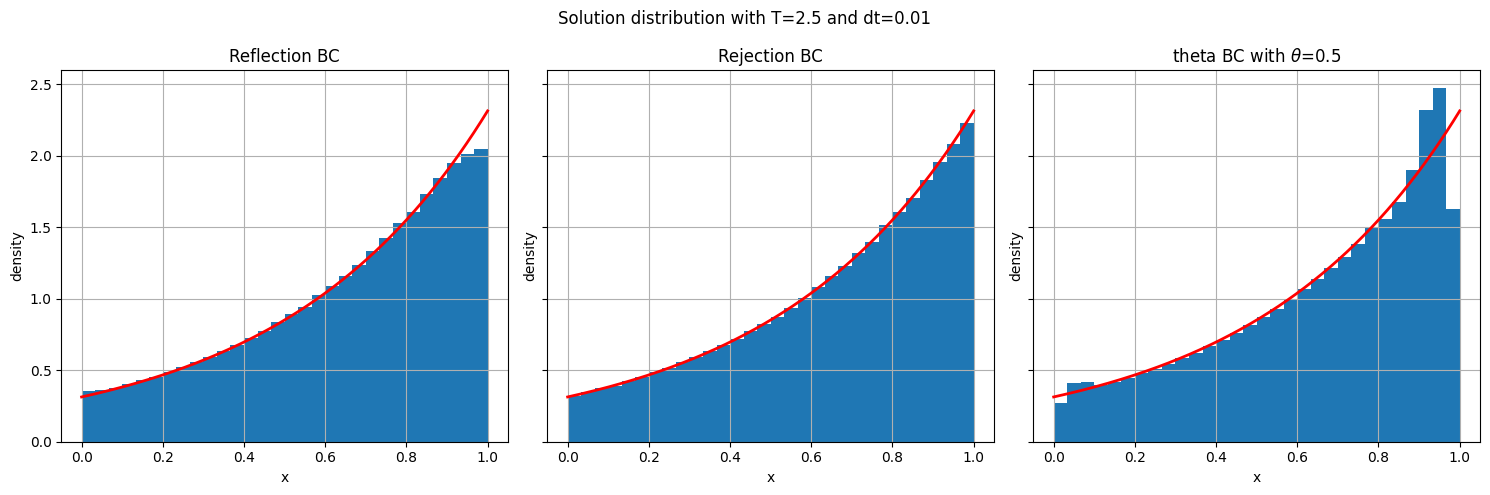

In [17]:
#compute the true solution
x_plot = np.linspace(bc_1, bc_2, 500)
p_exact = stationary_solution(x_plot, b, sigma, (bc_1, bc_2))

# plot full histogram
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)

fig.suptitle(f"Solution distribution with {T=} and {dt=}")

plot_histogram(X=X_ref, bins=30, ax=ax[0], title='Reflection BC',x_label='x', y_label='density', density=True
               , x_limit=None)
ax[0].plot(x_plot, p_exact, "r", linewidth=2)

plot_histogram(X=X_rej, bins=30, ax=ax[1], title='Rejection BC', x_label='x', y_label='density', density=True
               , x_limit=None)
ax[1].plot(x_plot, p_exact, "r", linewidth=2)

plot_histogram(X=X_theta, bins=30, ax=ax[2], title=fr'theta BC with $\theta$={0.5}', x_label='x', y_label='density', density=True
               , x_limit=None)
ax[2].plot(x_plot, p_exact, "r", linewidth=2)

plt.tight_layout()
plt.show()

In [18]:
T = 10
dt = 0.01
n_steps = int(T/ dt)
epsilon = np.sqrt(dt)

X_ref, steps_ref, solutions_ref = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps
                                                     , b=b, sigma=sigma, boundary_type="reflection"
                                                     , boundaries=(bc_1, bc_2), save_every=None)

X_rej, steps_rej, solutions_rej = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps, b=b, sigma=sigma
                                                     , boundary_type="rejection", boundaries=(bc_1, bc_2)
                                                     , save_every=None)

X_theta, steps_theta, solutions_theta = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps, b=b, sigma=sigma
                                                     , boundary_type=("theta", 0.5) , boundaries=(bc_1, bc_2)
                                                     , save_every=None)


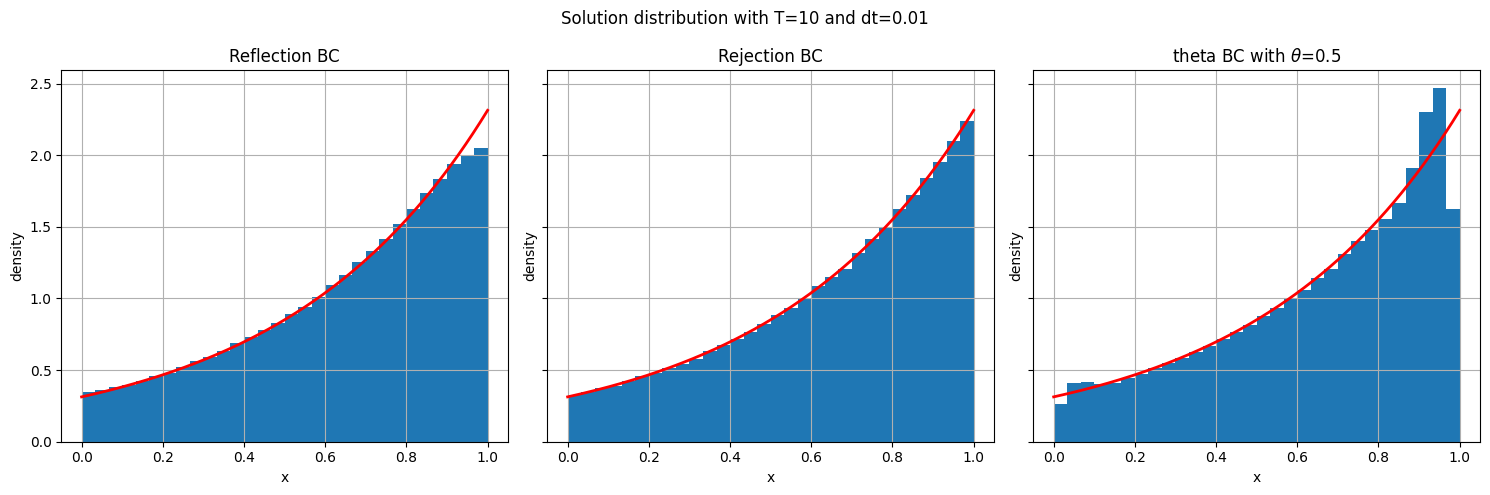

In [19]:
#compute the true solution
x_plot = np.linspace(bc_1, bc_2, 500)
p_exact = stationary_solution(x_plot, b, sigma, (bc_1, bc_2))

# plot full histogram
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)

fig.suptitle(f"Solution distribution with {T=} and {dt=}")

plot_histogram(X=X_ref, bins=30, ax=ax[0], title='Reflection BC',x_label='x', y_label='density', density=True
               , x_limit=None)
ax[0].plot(x_plot, p_exact, "r", linewidth=2)

plot_histogram(X=X_rej, bins=30, ax=ax[1], title='Rejection BC', x_label='x', y_label='density', density=True
               , x_limit=None)
ax[1].plot(x_plot, p_exact, "r", linewidth=2)

plot_histogram(X=X_theta, bins=30, ax=ax[2], title=fr'theta BC with $\theta$={0.5}', x_label='x', y_label='density', density=True
               , x_limit=None)
ax[2].plot(x_plot, p_exact, "r", linewidth=2)

plt.tight_layout()
plt.show()